In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.svm import SVC

In [2]:
df = pd.read_csv('CKD.csv')

df = pd.get_dummies(df, drop_first=True)
indep = df.drop('classification_yes', axis=1)
dep = df['classification_yes']
df.head()

,age,bp,al,su,bgr,bu,sc,sod,pot,hrmo,...,pc_normal,pcc_present,ba_present,htn_yes,dm_yes,cad_yes,appet_yes,pe_yes,ane_yes,classification_yes
0,2.0,76.459948,3.0,0.0,148.112676,57.482105,3.077356,137.528754,4.627244,12.518156,...,False,False,False,False,False,False,True,True,False,True
1,3.0,76.459948,2.0,0.0,148.112676,22.000000,0.700000,137.528754,4.627244,10.700000,...,True,False,False,False,False,False,True,False,False,True
2,4.0,76.459948,1.0,0.0,99.000000,23.000000,0.600000,138.000000,4.400000,12.000000,...,True,False,False,False,False,False,True,False,False,True
3,5.0,76.459948,1.0,0.0,148.112676,16.000000,0.700000,138.000000,3.200000,8.100000,...,True,False,False,False,False,False,True,False,True,True
4,5.0,50.000000,0.0,0.0,148.112676,25.000000,0.600000,137.528754,4.627244,11.800000,...,True,False,False,False,False,False,True,False,False,True


In [8]:
X_train, X_test, y_train, y_test = train_test_split(indep, dep, test_size=0.2, random_state=42)

param_grid = {'kernel':['rbf'],
                'C':[100,1000,2000,3000]}

gsv = GridSearchCV(SVC(probability=True), param_grid, cv=3, verbose=1, n_jobs=4)
gsv.fit(X_train, y_train)
gsv.best_params_

Fitting 3 folds for each of 4 candidates, totalling 12 fits


{'C': 3000, 'kernel': 'rbf'}

{'C': 3000, 'kernel': 'rbf'}
SVC(C=3000, probability=True)
              precision    recall  f1-score   support

       False       1.00      0.82      0.90        39
        True       0.85      1.00      0.92        41

    accuracy                           0.91        80
   macro avg       0.93      0.91      0.91        80
weighted avg       0.93      0.91      0.91        80



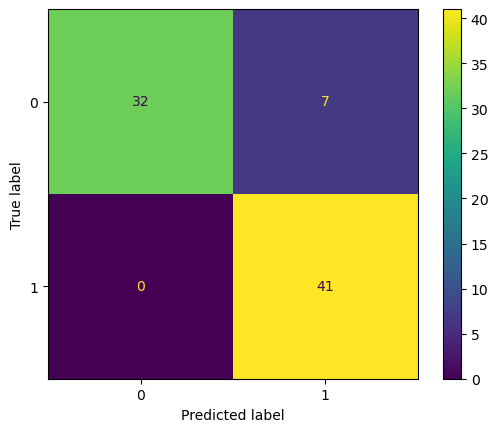

In [10]:

print(gsv.best_params_)
print(gsv.best_estimator_)
re = gsv.cv_results_

gsv.predict(X_test)
y_pred = gsv.predict(X_test)

from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay, f1_score
print(classification_report(y_test, y_pred))

cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(cm)
disp.plot()
plt.show()



In [11]:
f1 = f1_score(y_test, y_pred)
print("F1 Score= ",f1)

F1 Score=  0.9213483146067416
